In [ ]:
import nltk.data
print(nltk.data.path)

['/root/nltk_data', '/usr/nltk_data', '/usr/share/nltk_data', '/usr/lib/nltk_data', '/usr/share/nltk_data', '/usr/local/share/nltk_data', '/usr/lib/nltk_data', '/usr/local/lib/nltk_data']


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Training Word2Vec models...
X_train shape: (841, 100)
y_train shape: (841, 4)
X_test shape: (150, 100)
y_test shape: (150, 4)

Training CBOW Model...
Epoch 1/15


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - accuracy: 0.2661 - loss: 1.3935

27/27 ━━━━━━━━━━━━━━━━━━━━ 26s 650ms/step - accuracy: 0.2668 - loss: 1.3935 - val_accuracy: 0.0800 - val_loss: 1.5689
Epoch 2/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step - accuracy: 0.2850 - loss: 1.3765

27/27 ━━━━━━━━━━━━━━━━━━━━ 23s 771ms/step - accuracy: 0.2850 - loss: 1.3765 - val_accuracy: 0.1267 - val_loss: 1.5133
Epoch 3/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 36s 576ms/step - accuracy: 0.2635 - loss: 1.3874 - val_accuracy: 0.0867 - val_loss: 1.6703
Epoch 4/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 511ms/step - accuracy: 0.2638 - loss: 1.3630 - val_accuracy: 0.0800 - val_loss: 1.5793
Epoch 5/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 14s 534ms/step - accuracy: 0.2827 - loss: 1.3705 - val_accuracy: 0.1000 - val_loss: 1.5699
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - accuracy: 0.1316 - loss: 1.5124

Training Skip-gram Model...
Epoch 1/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 23s 551ms/step - accuracy: 0.2437 - loss: 1.3871 - val_accuracy: 0.0733 - val_loss: 1.6135
Epoch 2/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 21s 547ms/step - accuracy: 0.2722 - loss: 1.3849 - val_accuracy: 0.0800 - val_loss: 1.6672
Epoch 3/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 521ms/step - accuracy: 0.2935 - loss: 1.3630 - val_accuracy: 0.0733 - val_loss: 1.5589
Epoch 

27/27 ━━━━━━━━━━━━━━━━━━━━ 22s 549ms/step - accuracy: 0.2730 - loss: 1.4043 - val_accuracy: 0.1667 - val_loss: 1.4965
Epoch 2/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 20s 513ms/step - accuracy: 0.2781 - loss: 1.3827 - val_accuracy: 0.1667 - val_loss: 1.6152
Epoch 3/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 21s 533ms/step - accuracy: 0.2686 - loss: 1.3851 - val_accuracy: 0.1667 - val_loss: 1.5644
Epoch 4/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 21s 538ms/step - accuracy: 0.3129 - loss: 1.3600 - val_accuracy: 0.0800 - val_loss: 1.5266
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 246ms/step - accuracy: 0.0595 - loss: 1.4971

Training Trainable Embeddings Model (substitute for ELMo)...
Epoch 1/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 24s 608ms/step - accuracy: 0.2754 - loss: 1.4050 - val_accuracy: 0.1667 - val_loss: 1.6799
Epoch 2/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 16s 599ms/step - accuracy: 0.2772 - loss: 1.3769 - val_accuracy: 0.0800 - val_loss: 1.5516
Epoch 3/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 20s 586ms/step - accuracy: 0.2541 - loss: 1.3949 - val_accuracy:

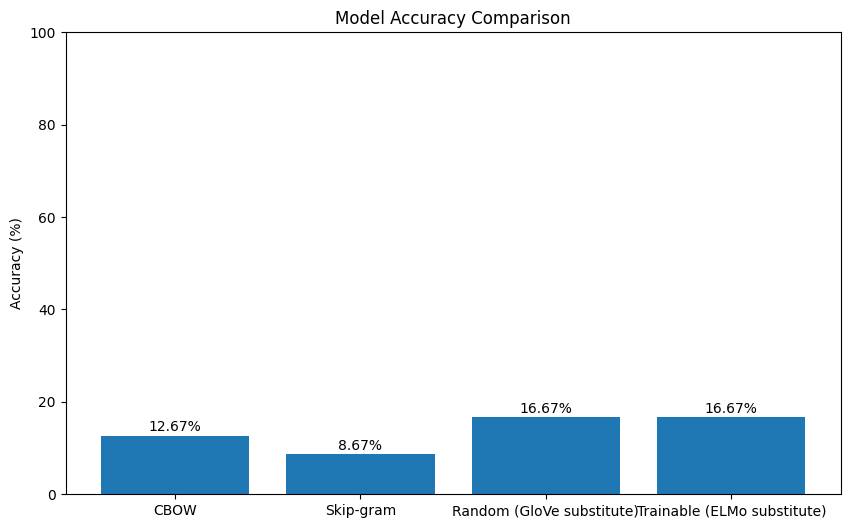

In [ ]:
import zipfile
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import re
import nltk
from nltk.tokenize import word_tokenize
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.initializers import Constant
from gensim.models import Word2Vec
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt


nltk.download('punkt')


zip_path = "data.zip"
extract_path = "data"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

train_df = pd.read_csv(os.path.join(extract_path, "Poem_classification - train_data.csv"))
test_df = pd.read_csv(os.path.join(extract_path, "Poem_classification - test_data.csv"))

text_column = 'Poem'
genre_column = 'Genre'


train_df[text_column] = train_df[text_column].fillna("")
test_df[text_column] = test_df[text_column].fillna("")


def clean_text(text):
    if isinstance(text, str):
        text = text.lower()
        text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
        return text
    return ""


train_df[text_column] = train_df[text_column].apply(clean_text)
test_df[text_column] = test_df[text_column].apply(clean_text)


def tokenize_text(text):
    return text.split()

train_df['tokens'] = train_df[text_column].apply(tokenize_text)
test_df['tokens'] = test_df[text_column].apply(tokenize_text)



all_sentences = list(train_df['tokens']) + list(test_df['tokens'])


print("Training Word2Vec models...")

cbow_model = Word2Vec(sentences=all_sentences, vector_size=100, window=5, min_count=1, workers=4, sg=0)

skipgram_model = Word2Vec(sentences=all_sentences, vector_size=100, window=5, min_count=1, workers=4, sg=1)


tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_df[text_column])

vocab_size = len(tokenizer.word_index) + 1
max_length = 100

X_train = pad_sequences(tokenizer.texts_to_sequences(train_df[text_column]), maxlen=max_length)
X_test = pad_sequences(tokenizer.texts_to_sequences(test_df[text_column]), maxlen=max_length)


y_train = pd.get_dummies(train_df[genre_column]).values
y_test = pd.get_dummies(test_df[genre_column]).values

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")


def create_embedding_matrix_from_word2vec(model, word_index, embedding_dim=100):
    embedding_matrix = np.zeros((len(word_index) + 1, embedding_dim))
    for word, i in word_index.items():
        try:
            embedding_matrix[i] = model.wv[word]
        except KeyError:

            pass
    return embedding_matrix


cbow_embedding_matrix = create_embedding_matrix_from_word2vec(cbow_model, tokenizer.word_index)
skipgram_embedding_matrix = create_embedding_matrix_from_word2vec(skipgram_model, tokenizer.word_index)


random_embedding_matrix = np.random.rand(vocab_size, 100)


def create_model(embedding_matrix, trainable=False, name="model"):
    model = Sequential([
        Embedding(vocab_size, 100, weights=[embedding_matrix], input_length=max_length, trainable=trainable),
        Bidirectional(LSTM(128, return_sequences=True)),
        Bidirectional(LSTM(64)),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dense(y_train.shape[1], activation='softmax')
    ], name=name)

    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model


checkpoint = ModelCheckpoint("best_model.h5", monitor='val_accuracy', save_best_only=True, mode='max')
early_stopping = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)


results = {}


print("\nTraining CBOW Model...")
cbow_model = create_model(cbow_embedding_matrix, name="CBOW")
cbow_history = cbow_model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[checkpoint, early_stopping],
    verbose=1
)
cbow_loss, cbow_accuracy = cbow_model.evaluate(X_test, y_test)
results['CBOW'] = cbow_accuracy


print("\nTraining Skip-gram Model...")
skipgram_model = create_model(skipgram_embedding_matrix, name="Skip-gram")
skipgram_history = skipgram_model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[checkpoint, early_stopping],
    verbose=1
)
skipgram_loss, skipgram_accuracy = skipgram_model.evaluate(X_test, y_test)
results['Skip-gram'] = skipgram_accuracy


print("\nTraining Random Embeddings Model (substitute for GloVe)...")
random_model = create_model(random_embedding_matrix, name="Random_Embeddings")
random_history = random_model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[checkpoint, early_stopping],
    verbose=1
)
random_loss, random_accuracy = random_model.evaluate(X_test, y_test)
results['Random (GloVe substitute)'] = random_accuracy


print("\nTraining Trainable Embeddings Model (substitute for ELMo)...")
trainable_model = create_model(random_embedding_matrix, trainable=True, name="Trainable_Embeddings")
trainable_history = trainable_model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[checkpoint, early_stopping],
    verbose=1
)
trainable_loss, trainable_accuracy = trainable_model.evaluate(X_test, y_test)
results['Trainable (ELMo substitute)'] = trainable_accuracy

print("\n===== MODEL EVALUATION RESULTS =====")
for model_name, accuracy in results.items():
    print(f"{model_name} Model Accuracy: {accuracy * 100:.2f}%")


plt.figure(figsize=(10, 6))
models = list(results.keys())
accuracies = [results[model] * 100 for model in models]
plt.bar(models, accuracies)
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 100)
for i, v in enumerate(accuracies):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center')
plt.savefig('model_comparison.png')
print("Model comparison plot saved as 'model_comparison.png'")